##Step 0: Install and import libraries

In [ ]:
# ============================================================
# Phase 2: Model Training and Evaluation
# Models: Naive Bayes, Logistic Regression, SVM/LinearSVC, RoBERTa
# ============================================================

!pip install transformers datasets accelerate -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import torch

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

## Step 1: Upload and load Phase 1 dataset

In [ ]:
# ============================================================
# Step 1: Upload and Load Dataset
# ============================================================

uploaded = files.upload()
csv_file = list(uploaded.keys())[0]

df = pd.read_csv(csv_file)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Saving phase1_done.csv to phase1_done (1).csv
Dataset shape: (6513, 6)
Columns: ['id', 'message', 'translated_message', 'compound_score', 'sentiment_label', 'cleaned_text']


,id,message,translated_message,compound_score,sentiment_label,cleaned_text
0,1,Lelaki ini wajib disabitkan atas niat membunuh...,This man is supposed to be mentioned for his p...,-0.6542,Negative,man supposed mentioned purpose killing victim ...
1,2,Lelaki ini wajib disabitkan atas niat membunuh...,This man is responsible for his murder. He is ...,-0.8176,Negative,man responsible murder main cause death family...
2,3,Tak nak letak harapan tinggi dpd pihak berkuas...,The high hopes of the authorities are not alwa...,0.8674,Positive,high hope authority always high police hoping ...
3,4,Kes ustazah outo kena tersilap tekan minyak ni...,Car crashing car's got a bad turn to oil runni...,-0.5423,Negative,car crashing car got bad turn oil running death
4,5,Muka x bersalah langsung …,You're wrong about x right now...,-0.4767,Negative,youre wrong x right


## Step 2: Dataset checking

In [ ]:
# ============================================================
# Step 2: Dataset Checking
# ============================================================

required_columns = ["translated_message", "cleaned_text", "sentiment_label"]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# Remove missing or empty values
df = df.dropna(subset=["translated_message", "cleaned_text", "sentiment_label"])
df = df[df["cleaned_text"].astype(str).str.strip() != ""]
df = df[df["translated_message"].astype(str).str.strip() != ""]
df = df.reset_index(drop=True)

print("Dataset after checking:", df.shape)

print("\nSentiment label distribution:")
print(df["sentiment_label"].value_counts())

print("\nSentiment label percentage:")
print((df["sentiment_label"].value_counts(normalize=True) * 100).round(2))

Dataset after checking: (6513, 6)

Sentiment label distribution:
sentiment_label
Neutral     2975
Negative    1936
Positive    1602
Name: count, dtype: int64

Sentiment label percentage:
sentiment_label
Neutral     45.68
Negative    29.73
Positive    24.60
Name: proportion, dtype: float64


## Step 3: Train-test split with stratify

In [ ]:
# ============================================================
# Step 3: Train-Test Split
# ============================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment_label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training set:", train_df.shape)
print("Testing set:", test_df.shape)

print("\nTraining label distribution:")
print(train_df["sentiment_label"].value_counts())

print("\nTesting label distribution:")
print(test_df["sentiment_label"].value_counts())

Training set: (5210, 6)
Testing set: (1303, 6)

Training label distribution:
sentiment_label
Neutral     2380
Negative    1549
Positive    1281
Name: count, dtype: int64

Testing label distribution:
sentiment_label
Neutral     595
Negative    387
Positive    321
Name: count, dtype: int64


## Step 4: TF-IDF feature extraction

In [ ]:
# ============================================================
# Step 4: TF-IDF Feature Extraction
# ============================================================

X_train_text = train_df["cleaned_text"].astype(str)
X_test_text = test_df["cleaned_text"].astype(str)

y_train = train_df["sentiment_label"]
y_test = test_df["sentiment_label"]

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (5210, 3939)
X_test_tfidf shape: (1303, 3939)


## Step 5: Evaluation function

In [ ]:
# ============================================================
# Step 5: Evaluation Function
# ============================================================

all_results = []

def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    print("\n====================================================")
    print(f"{model_name} Evaluation Result")
    print("====================================================")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall: {recall_macro:.4f}")
    print(f"Macro F1-score: {f1_macro:.4f}")
    print(f"Weighted F1-score: {f1_weighted:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    result = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": precision_macro,
        "Macro Recall": recall_macro,
        "Macro F1-score": f1_macro,
        "Weighted F1-score": f1_weighted
    }

    all_results.append(result)
    return result

## Step 6: Confusion matrix function

In [ ]:
# ============================================================
# Step 6: Confusion Matrix Function
# ============================================================

labels = ["Negative", "Neutral", "Positive"]

def plot_and_save_confusion_matrix(y_true, y_pred, model_name, file_name):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(file_name, dpi=300)
    plt.show()

## Step 7: Model 1 — Naive Bayes


Naive Bayes Evaluation Result
Accuracy: 0.7130
Macro Precision: 0.7361
Macro Recall: 0.6590
Macro F1-score: 0.6742
Weighted F1-score: 0.6978

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.58      0.65       387
     Neutral       0.69      0.93      0.79       595
    Positive       0.79      0.46      0.58       321

    accuracy                           0.71      1303
   macro avg       0.74      0.66      0.67      1303
weighted avg       0.73      0.71      0.70      1303



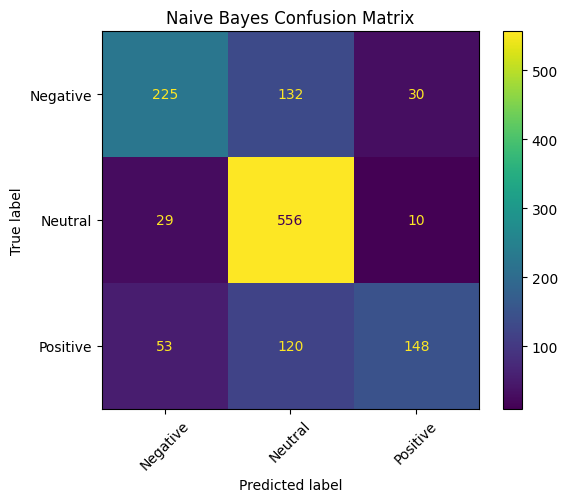

In [ ]:
# ============================================================
# Step 7: Train Model 1 - Naive Bayes
# ============================================================

nb_model = MultinomialNB(alpha=1.0)

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

nb_result = evaluate_model("Naive Bayes", y_test, y_pred_nb)

plot_and_save_confusion_matrix(
    y_test,
    y_pred_nb,
    "Naive Bayes",
    "naive_bayes_confusion_matrix.png"
)

## Step 8: Model 2 — Logistic Regression


Logistic Regression Evaluation Result
Accuracy: 0.7667
Macro Precision: 0.7553
Macro Recall: 0.7437
Macro F1-score: 0.7476
Weighted F1-score: 0.7640

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.66      0.71       387
     Neutral       0.80      0.87      0.84       595
    Positive       0.70      0.70      0.70       321

    accuracy                           0.77      1303
   macro avg       0.76      0.74      0.75      1303
weighted avg       0.77      0.77      0.76      1303



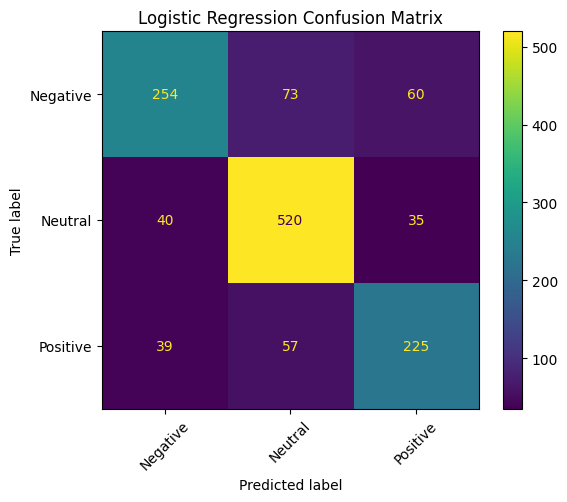

In [ ]:
# ============================================================
# Step 8: Train Model 2 - Logistic Regression
# ============================================================

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

lr_result = evaluate_model("Logistic Regression", y_test, y_pred_lr)

plot_and_save_confusion_matrix(
    y_test,
    y_pred_lr,
    "Logistic Regression",
    "logistic_regression_confusion_matrix.png"
)

## Step 9: Model 3 — SVM / LinearSVC


SVM / LinearSVC Evaluation Result
Accuracy: 0.7974
Macro Precision: 0.7877
Macro Recall: 0.7710
Macro F1-score: 0.7772
Weighted F1-score: 0.7941

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.70      0.74       387
     Neutral       0.82      0.91      0.87       595
    Positive       0.75      0.70      0.72       321

    accuracy                           0.80      1303
   macro avg       0.79      0.77      0.78      1303
weighted avg       0.80      0.80      0.79      1303



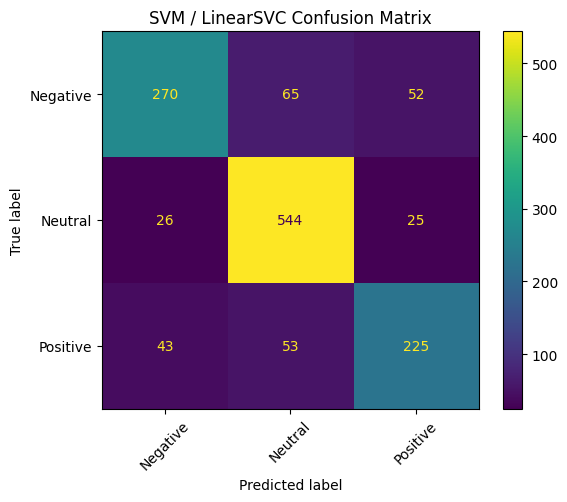

In [ ]:
# ============================================================
# Step 9: Train Model 3 - SVM / LinearSVC
# ============================================================

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

svm_result = evaluate_model("SVM / LinearSVC", y_test, y_pred_svm)

plot_and_save_confusion_matrix(
    y_test,
    y_pred_svm,
    "SVM / LinearSVC",
    "svm_linearsvc_confusion_matrix.png"
)

##Part B: Transformer Model — RoBERTa

## Step 10: Prepare labels for RoBERTa

In [ ]:
# ============================================================
# Step 10: Prepare Labels for RoBERTa
# ============================================================

label2id = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

id2label = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

train_texts = train_df["translated_message"].astype(str).tolist()
test_texts = test_df["translated_message"].astype(str).tolist()

train_labels = train_df["sentiment_label"].map(label2id).tolist()
test_labels = test_df["sentiment_label"].map(label2id).tolist()

print("Train size:", len(train_texts))
print("Test size:", len(test_texts))

Train size: 5210
Test size: 1303


## Step 11: Tokenizer + custom PyTorch Dataset

In [ ]:
# ============================================================
# Step 11: Tokenization + Custom Dataset
# ============================================================

import torch
from torch.utils.data import Dataset

model_checkpoint = "distilroberta-base"
# 如果 GPU 够强，可以改成：
# model_checkpoint = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = SentimentDataset(train_encodings, train_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

print("Custom PyTorch datasets created successfully.")

Custom PyTorch datasets created successfully.


## Step 12: Load RoBERTa model

In [ ]:
# ============================================================
# Step 12: Load Transformer Model
# ============================================================

bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print("Model loaded:", model_checkpoint)

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilroberta-base


## Step 13: Metrics function

In [ ]:
# ============================================================
# Step 13: Metrics Function
# ============================================================

import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels_true = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels_true, predictions)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels_true,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro
    }

## Step 14: Train RoBERTa

In [ ]:
# ============================================================
# Step 14: Train RoBERTa / BERT-based Model
# ============================================================

training_args = TrainingArguments(
    output_dir="./roberta_sentiment_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none",
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.461878,0.443171,0.840368,0.830064,0.837123,0.830316
2,0.354816,0.448152,0.875672,0.863198,0.867534,0.865101


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1304, training_loss=0.4987529633463892, metrics={'train_runtime': 7885.1755, 'train_samples_per_second': 1.321, 'train_steps_per_second': 0.165, 'total_flos': 345083727467520.0, 'train_loss': 0.4987529633463892, 'epoch': 2.0})

## Step 15: Evaluate RoBERTa

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



RoBERTa / BERT-based Model Evaluation Result
Accuracy: 0.8757
Macro Precision: 0.8632
Macro Recall: 0.8675
Macro F1-score: 0.8651
Weighted F1-score: 0.8762

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.88      0.85       387
     Neutral       0.94      0.90      0.92       595
    Positive       0.82      0.82      0.82       321

    accuracy                           0.88      1303
   macro avg       0.86      0.87      0.87      1303
weighted avg       0.88      0.88      0.88      1303



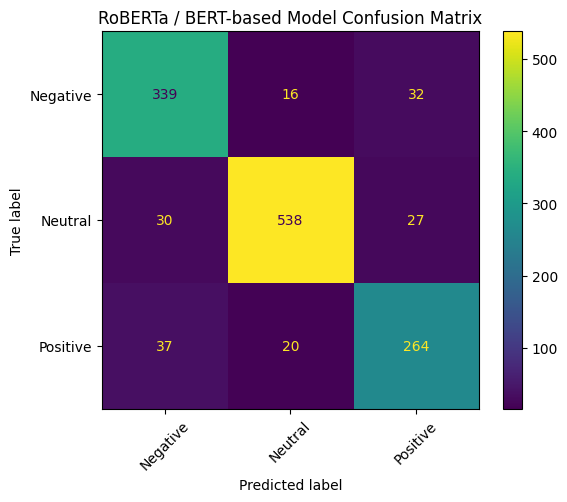

In [ ]:
# ============================================================
# Step 15: Evaluate RoBERTa
# ============================================================

bert_predictions = trainer.predict(test_dataset)

bert_logits = bert_predictions.predictions
bert_y_pred_ids = np.argmax(bert_logits, axis=-1)

bert_y_true_ids = np.array(test_labels)

bert_y_pred = [id2label[i] for i in bert_y_pred_ids]
bert_y_true = [id2label[i] for i in bert_y_true_ids]

bert_result = evaluate_model(
    "RoBERTa / BERT-based Model",
    bert_y_true,
    bert_y_pred
)

plot_and_save_confusion_matrix(
    bert_y_true,
    bert_y_pred,
    "RoBERTa / BERT-based Model",
    "roberta_confusion_matrix.png"
)

## Step 16: Save RoBERTa model

In [ ]:
# ============================================================
# Step 16: Save RoBERTa Model
# ============================================================

trainer.save_model("roberta_sentiment_final")
tokenizer.save_pretrained("roberta_sentiment_final")

print("RoBERTa model saved in folder: roberta_sentiment_final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RoBERTa model saved in folder: roberta_sentiment_final


## Part C: Final Comparison and Save All Models
## Step 17: Compare all 4 model

In [ ]:
# ============================================================
# Step 17: Final Model Comparison
# ============================================================

comparison_df = pd.DataFrame(all_results)

comparison_df = comparison_df.sort_values(
    by="Macro F1-score",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted F1-score
0,RoBERTa / BERT-based Model,0.875672,0.863198,0.867534,0.865101,0.876226
1,SVM / LinearSVC,0.797391,0.787749,0.770965,0.777222,0.794104
2,Logistic Regression,0.766692,0.755296,0.743738,0.747642,0.763952
3,Naive Bayes,0.712970,0.736084,0.658969,0.674178,0.697773


In [ ]:
comparison_df.to_csv("all_model_comparison_results.csv", index=False)

print("Final model comparison saved as all_model_comparison_results.csv")

Final model comparison saved as all_model_comparison_results.csv


## Step 18: Save traditional ML models and vectorizer

In [ ]:
# ============================================================
# Step 18: Save Traditional ML Models and Vectorizer
# ============================================================

joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(nb_model, "naive_bayes_model.pkl")
joblib.dump(lr_model, "logistic_regression_model.pkl")
joblib.dump(svm_model, "svm_linearsvc_model.pkl")

# Select best traditional model only
traditional_results = comparison_df[
    comparison_df["Model"].isin([
        "Naive Bayes",
        "Logistic Regression",
        "SVM / LinearSVC"
    ])
]

best_traditional_model_name = traditional_results.iloc[0]["Model"]

if best_traditional_model_name == "Naive Bayes":
    best_traditional_model = nb_model
elif best_traditional_model_name == "Logistic Regression":
    best_traditional_model = lr_model
else:
    best_traditional_model = svm_model

joblib.dump(best_traditional_model, "best_traditional_model.pkl")

print("Saved files:")
print("- tfidf_vectorizer.pkl")
print("- naive_bayes_model.pkl")
print("- logistic_regression_model.pkl")
print("- svm_linearsvc_model.pkl")
print("- best_traditional_model.pkl")
print("- all_model_comparison_results.csv")

Saved files:
- tfidf_vectorizer.pkl
- naive_bayes_model.pkl
- logistic_regression_model.pkl
- svm_linearsvc_model.pkl
- best_traditional_model.pkl
- all_model_comparison_results.csv


## Step 19: Test prediction using traditional models

In [ ]:
# ============================================================
# Step 19: Test New Comment Prediction with Traditional Models
# ============================================================

def predict_traditional(comment, model):
    comment_tfidf = tfidf_vectorizer.transform([comment])
    prediction = model.predict(comment_tfidf)[0]
    return prediction

sample_comments = [
    "This promotion is really worth it and I love it",
    "The discount is fake and very disappointing",
    "The event will start tomorrow at 8pm"
]

for comment in sample_comments:
    print("\nComment:", comment)
    print("Naive Bayes:", predict_traditional(comment, nb_model))
    print("Logistic Regression:", predict_traditional(comment, lr_model))
    print("SVM / LinearSVC:", predict_traditional(comment, svm_model))


Comment: This promotion is really worth it and I love it
Naive Bayes: Positive
Logistic Regression: Positive
SVM / LinearSVC: Positive

Comment: The discount is fake and very disappointing
Naive Bayes: Negative
Logistic Regression: Neutral
SVM / LinearSVC: Neutral

Comment: The event will start tomorrow at 8pm
Naive Bayes: Neutral
Logistic Regression: Neutral
SVM / LinearSVC: Neutral


## Step 20: Test prediction using RoBERTa

In [ ]:
# ============================================================
# Step 20: Test New Comment Prediction with RoBERTa
# ============================================================

def predict_roberta(comment):
    inputs = tokenizer(
        comment,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    bert_model.to(device)

    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = bert_model(**inputs)
        predicted_id = torch.argmax(outputs.logits, dim=1).item()

    return id2label[predicted_id]

for comment in sample_comments:
    print("\nComment:", comment)
    print("RoBERTa Prediction:", predict_roberta(comment))


Comment: This promotion is really worth it and I love it
RoBERTa Prediction: Positive

Comment: The discount is fake and very disappointing
RoBERTa Prediction: Negative

Comment: The event will start tomorrow at 8pm
RoBERTa Prediction: Neutral


## Step 21: Download important files

In [ ]:
# ============================================================
# Step 21: Download Output Files
# ============================================================

from google.colab import files
import os
import shutil

files.download("tfidf_vectorizer.pkl")
files.download("naive_bayes_model.pkl")
files.download("logistic_regression_model.pkl")
files.download("svm_linearsvc_model.pkl")
files.download("best_traditional_model.pkl")
files.download("all_model_comparison_results.csv")

files.download("naive_bayes_confusion_matrix.png")
files.download("logistic_regression_confusion_matrix.png")
files.download("svm_linearsvc_confusion_matrix.png")
files.download("roberta_confusion_matrix.png")


# ============================================================
# Download RoBERTa Saved Model Folder
# ============================================================

folder_name = "roberta_sentiment_final"

if os.path.exists(folder_name):
    print("RoBERTa model folder exists.")
    print("Files inside the folder:")
    print(os.listdir(folder_name))

    # Zip the RoBERTa model folder
    shutil.make_archive(folder_name, "zip", folder_name)

    # Download the zipped folder
    files.download(folder_name + ".zip")

else:
    print("RoBERTa model folder not found. Please run Step 16 again first.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>